In [100]:
import pandas as pd

In [101]:
import pandas as pd

df = pd.read_csv("../data/50000 Sales Records.csv",parse_dates=["Order Date","Ship Date"])

In [102]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Sub-Saharan Africa,Namibia,Household,Offline,M,2015-08-31,897751939,2015-10-12,3604,668.27,502.54,2408445.08,1811154.16,597290.92
1,Europe,Iceland,Baby Food,Online,H,2010-11-20,599480426,2011-01-09,8435,255.28,159.42,2153286.80,1344707.70,808579.10
2,Europe,Russia,Meat,Online,L,2017-06-22,538911855,2017-06-25,4848,421.89,364.69,2045322.72,1768017.12,277305.60
3,Europe,Moldova,Meat,Online,L,2012-02-28,459845054,2012-03-20,7225,421.89,364.69,3048155.25,2634885.25,413270.00
4,Europe,Malta,Cereal,Online,M,2010-08-12,626391351,2010-09-13,1975,205.70,117.11,406257.50,231292.25,174965.25


In [103]:
df.shape

(50000, 14)

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Region          50000 non-null  object        
 1   Country         50000 non-null  object        
 2   Item Type       50000 non-null  object        
 3   Sales Channel   50000 non-null  object        
 4   Order Priority  50000 non-null  object        
 5   Order Date      50000 non-null  datetime64[ns]
 6   Order ID        50000 non-null  int64         
 7   Ship Date       50000 non-null  datetime64[ns]
 8   Units Sold      50000 non-null  int64         
 9   Unit Price      50000 non-null  float64       
 10  Unit Cost       50000 non-null  float64       
 11  Total Revenue   50000 non-null  float64       
 12  Total Cost      50000 non-null  float64       
 13  Total Profit    50000 non-null  float64       
dtypes: datetime64[ns](2), float64(5), int64(2), object(5)


In [105]:
df.isna().sum()

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [106]:
df.duplicated().sum()

np.int64(0)

In [107]:
df.describe()

,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,50000,5.000000e+04,50000,50000.00000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04
mean,2013-10-11 06:32:29.184000,5.497330e+08,2013-11-05 06:39:15.264000,4999.61898,265.651350,187.322482,1.323716e+06,9.331574e+05,3.905587e+05
min,2010-01-01 00:00:00,1.000132e+08,2010-01-02 00:00:00,1.00000,9.330000,6.920000,2.799000e+01,2.076000e+01,7.230000e+00
25%,2011-11-15 00:00:00,3.240070e+08,2011-12-11 00:00:00,2498.00000,81.730000,35.840000,2.764871e+05,1.606370e+05,9.415092e+04
50%,2013-10-09 00:00:00,5.504224e+08,2013-11-02 00:00:00,5017.50000,154.060000,97.440000,7.813247e+05,4.671040e+05,2.795364e+05
75%,2015-09-04 00:00:00,7.767824e+08,2015-09-30 00:00:00,7493.25000,421.890000,263.330000,1.808642e+06,1.190390e+06,5.642867e+05
max,2017-07-28 00:00:00,9.999995e+08,2017-09-16 00:00:00,10000.00000,668.270000,524.960000,6.682032e+06,5.249075e+06,1.738178e+06
std,NaN,2.609179e+08,NaN,2884.33508,216.916752,175.580570,1.463891e+06,1.145548e+06,3.777588e+05


In [108]:
df["Order ID"].nunique()

50000

In [109]:
len(df)

50000

In [110]:
df['Order ID'].duplicated().sum()

np.int64(0)

In [111]:
(df["Units Sold"] * df["Unit Price"] - df["Total Revenue"]).abs().max()

9.313225746154785e-10

In [112]:
(df["Units Sold"] * df["Unit Cost"] - df["Total Cost"]).abs().max()

9.313225746154785e-10

In [113]:
(df["Total Revenue"] - df["Total Cost"] - df["Total Profit"]).abs().max()

6.984919309616089e-10

In [114]:
df["Order Date"].min()


Timestamp('2010-01-01 00:00:00')

In [115]:
df["Order Date"].max()

Timestamp('2017-07-28 00:00:00')

In [116]:
df["Order Date"].nunique()

2766

In [117]:
df["Order Date"].dt.year.value_counts().sort_index()

Order Date
2010    6594
2011    6757
2012    6634
2013    6523
2014    6596
2015    6570
2016    6551
2017    3775
Name: count, dtype: int64

In [118]:
df["Order Date"].dt.to_period("M").value_counts().sort_index()

Order Date
2010-01    502
2010-02    538
2010-03    531
2010-04    537
2010-05    548
          ... 
2017-03    563
2017-04    545
2017-05    610
2017-06    536
2017-07    480
Freq: M, Name: count, Length: 91, dtype: int64

In [119]:
d = df["Order Date"].dt.to_period("Y").value_counts().sort_index().reset_index()

In [120]:
d

,Order Date,count
0,2010,6594
1,2011,6757
2,2012,6634
3,2013,6523
4,2014,6596
5,2015,6570
6,2016,6551
7,2017,3775


In [121]:
monthly_demand = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Units Sold"]
      .sum()
      .reset_index()
)

monthly_demand.head(12)

,Order Date,Units Sold
0,2010-01,2416955
1,2010-02,2724860
2,2010-03,2557032
3,2010-04,2780481
4,2010-05,2757045
5,2010-06,2844228
6,2010-07,2676194
7,2010-08,3000733
8,2010-09,2692859
9,2010-10,2835289


In [122]:
monthly_demand["Units Sold"].describe()

count    9.100000e+01
mean     2.747043e+06
std      1.700930e+05
min      2.404223e+06
25%      2.646410e+06
50%      2.739138e+06
75%      2.869465e+06
max      3.092803e+06
Name: Units Sold, dtype: float64

In [123]:
monthly_demand.shape

(91, 2)

In [124]:
monthly_demand.sort_values("Units Sold", ascending=False).head(10)

,Order Date,Units Sold
52,2014-05,3092803
82,2016-11,3051106
71,2015-12,3039021
21,2011-10,3037996
28,2012-05,3031626
59,2014-12,3021706
7,2010-08,3000733
30,2012-07,2996787
36,2013-01,2974583
20,2011-09,2974414


In [125]:
monthly_demand.sort_values("Units Sold").head(10)

,Order Date,Units Sold
90,2017-07,2404223
0,2010-01,2416955
57,2014-10,2421817
37,2013-02,2421905
61,2015-02,2437945
49,2014-02,2456341
27,2012-04,2459399
83,2016-12,2477995
85,2017-02,2488645
63,2015-04,2496706


In [126]:
d

,Order Date,count
0,2010,6594
1,2011,6757
2,2012,6634
3,2013,6523
4,2014,6596
5,2015,6570
6,2016,6551
7,2017,3775


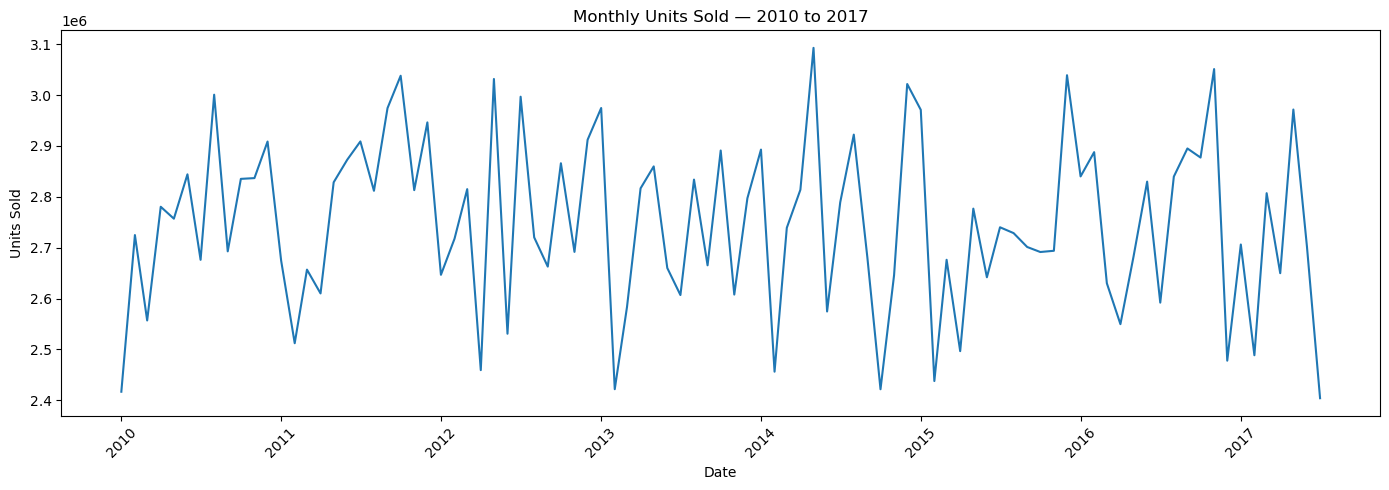

In [127]:
import matplotlib.pyplot as plt

monthly_demand["Order Date"] = monthly_demand["Order Date"].dt.to_timestamp()

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand["Order Date"],
    monthly_demand["Units Sold"]
)

plt.title("Monthly Units Sold — 2010 to 2017")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [128]:
monthly_demand["Month"] = monthly_demand["Order Date"].dt.month

In [129]:
monthly_demand.groupby("Month")["Units Sold"].agg(
    ["mean", "min", "max"]
)

,mean,min,max
Month,,,
1,2.765390e+06,2416955,2974583
2,2.580929e+06,2421905,2887814
3,2.683177e+06,2557032,2815082
4,2.647121e+06,2459399,2816701
5,2.875133e+06,2682846,3092803
6,2.707170e+06,2530941,2872964
7,2.714307e+06,2404223,2996787
8,2.836773e+06,2720263,3000733
9,2.753273e+06,2662857,2974414


In [130]:
expected_months = pd.date_range(
    start=monthly_demand["Order Date"].min(),
    end=monthly_demand["Order Date"].max(),
    freq="MS"
)

actual_months = monthly_demand["Order Date"]

missing_months = expected_months.difference(actual_months)

missing_months

DatetimeIndex([], dtype='datetime64[ns]', freq='MS')

In [131]:
print(df["Total Revenue"].sum())

print(df["Total Cost"].sum())


print(df["Total Profit"].sum())     


print(df["Units Sold"].sum())

print(df["Order ID"].nunique())

df["Total Profit"].sum() / df["Total Revenue"].sum() * 100

66185806881.22
46657869932.97
19527936948.25
249980949
50000


np.float64(29.504719921743504)

In [132]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg(
          orders=("Order ID", "count"),
          units_sold=("Units Sold", "sum"),
          revenue=("Total Revenue", "sum"),
          cost=("Total Cost", "sum"),
          profit=("Total Profit", "sum")
      )
      .reset_index()
)

In [133]:
monthly_sales.head()

,Order Date,orders,units_sold,revenue,cost,profit
0,2010-01,502,2416955,6.297848e+08,4.554190e+08,1.743658e+08
1,2010-02,538,2724860,7.697528e+08,5.491157e+08,2.206372e+08
2,2010-03,531,2557032,7.118628e+08,5.042874e+08,2.075755e+08
3,2010-04,537,2780481,7.383854e+08,5.191112e+08,2.192742e+08
4,2010-05,548,2757045,7.439784e+08,5.277816e+08,2.161968e+08


In [134]:
monthly_sales.shape

(91, 6)

In [135]:
monthly_sales["profit_margin"] = (
    monthly_sales["profit"] /
    monthly_sales["revenue"] * 100
)

In [136]:
monthly_sales.head()

,Order Date,orders,units_sold,revenue,cost,profit,profit_margin
0,2010-01,502,2416955,6.297848e+08,4.554190e+08,1.743658e+08,27.686564
1,2010-02,538,2724860,7.697528e+08,5.491157e+08,2.206372e+08,28.663377
2,2010-03,531,2557032,7.118628e+08,5.042874e+08,2.075755e+08,29.159478
3,2010-04,537,2780481,7.383854e+08,5.191112e+08,2.192742e+08,29.696442
4,2010-05,548,2757045,7.439784e+08,5.277816e+08,2.161968e+08,29.059551


In [137]:
categorical_cols = [
    "Region",
    "Country",
    "Item Type",
    "Sales Channel",
    "Order Priority"
]

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].unique())


Region
Unique values: 7
['Sub-Saharan Africa' 'Europe' 'Asia' 'Middle East and North Africa'
 'Central America and the Caribbean' 'Australia and Oceania'
 'North America']

Country
Unique values: 185
['Namibia' 'Iceland' 'Russia' 'Moldova ' 'Malta' 'Indonesia' 'Djibouti'
 'Greece' 'Cameroon' 'Nigeria' 'Senegal' 'Afghanistan' 'India' 'Lebanon'
 'Turkey' 'Iraq' 'Rwanda' 'Ukraine' 'Finland' 'South Sudan'
 'Antigua and Barbuda ' 'Kuwait' 'United Kingdom' 'Saint Kitts and Nevis '
 'Saint Lucia' 'Tunisia ' 'Yemen' 'Guinea' 'Tuvalu' 'South Korea'
 'San Marino' 'Trinidad and Tobago' 'Kosovo' 'Hungary' 'Botswana' 'Serbia'
 'Guatemala' 'United Arab Emirates' 'Samoa ' 'Bahrain'
 'Saint Vincent and the Grenadines' 'Pakistan' 'Poland' 'Lithuania'
 'Sudan' 'Portugal' 'Fiji' 'Tanzania' 'Sao Tome and Principe' 'Cape Verde'
 'Greenland' 'Guinea-Bissau' 'Georgia' 'Jamaica' 'Bulgaria' 'Kazakhstan'
 'Grenada' 'Honduras' 'Mongolia' 'Belize' 'United States of America'
 'South Africa' 'Austria' 'Marshall Is

In [138]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [139]:
df["Ship Date"].min(), df["Ship Date"].max()

(Timestamp('2010-01-02 00:00:00'), Timestamp('2017-09-16 00:00:00'))

In [141]:
df["Country"] = df["Country"].str.strip()

In [142]:
country_region_check = (
    df.groupby("Country")["Region"]
      .nunique()
      .sort_values(ascending=False)
)

country_region_check.head(10)

Country
Afghanistan            1
Albania                1
Algeria                1
Andorra                1
Angola                 1
Antigua and Barbuda    1
Armenia                1
Australia              1
Austria                1
Azerbaijan             1
Name: Region, dtype: int64

In [143]:
country_region_check.max()

1